# 03 - Collaborative Filtering
## Sistem Rekomendasi Produk Manufaktur

**Tujuan Notebook:**
- Implementasi User-Based Collaborative Filtering
- Menghitung cosine similarity antar customer
- Membuat fungsi rekomendasi berdasarkan nearest neighbors
- Evaluasi performa CF dengan metrik Precision@K dan Recall@K

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Preprocessed Data

In [2]:
# Load user-item matrix
user_item_matrix = pd.read_csv('../data/user_item_matrix.csv', index_col=0)

# Load product information
products = pd.read_csv('../data/products_cleaned.csv')

print(f"User-Item Matrix shape: {user_item_matrix.shape}")
print(f"Users: {user_item_matrix.shape[0]:,}")
print(f"Products: {user_item_matrix.shape[1]:,}")
print(f"\nProduct catalog: {len(products):,} products")

user_item_matrix.head()

User-Item Matrix shape: (5545, 4206)
Users: 5,545
Products: 4,206

Product catalog: 4,206 products


,10002,10080,10120,10123C,10123G,10124A,10124G,10125,10133,10134,...,90214T,90214V,90214Z,ADJUST,BANK CHARGES,C2,D,M,PADS,POST
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
12349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
12350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 3. Train-Test Split

In [3]:
print("=== Creating Train-Test Split ===")

# Create a copy for splitting
train_matrix = user_item_matrix.copy()
test_matrix = pd.DataFrame(0, index=user_item_matrix.index, columns=user_item_matrix.columns)

# For each user, randomly select 20% of their purchases for testing
np.random.seed(42)
test_ratio = 0.2

for user_id in user_item_matrix.index:
    # Get products purchased by this user
    purchased_products = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index.tolist()
    
    if len(purchased_products) > 1:  # Only split if user has more than 1 purchase
        # Randomly select products for test set
        n_test = max(1, int(len(purchased_products) * test_ratio))
        test_products = np.random.choice(purchased_products, size=n_test, replace=False)
        
        # Move selected products to test set
        for product in test_products:
            test_matrix.loc[user_id, product] = user_item_matrix.loc[user_id, product]
            train_matrix.loc[user_id, product] = 0

print(f"\nTrain set non-zero interactions: {(train_matrix > 0).sum().sum():,}")
print(f"Test set non-zero interactions: {(test_matrix > 0).sum().sum():,}")
print(f"Test ratio: {(test_matrix > 0).sum().sum() / (user_item_matrix > 0).sum().sum() * 100:.2f}%")

=== Creating Train-Test Split ===

Train set non-zero interactions: 386,372
Test set non-zero interactions: 93,849
Test ratio: 19.54%


## 4. Calculate User Similarity Matrix

In [4]:
print("=== Calculating User Similarity Matrix ===")
print("This may take a few minutes...\n")

# Calculate cosine similarity between all users
user_similarity = cosine_similarity(train_matrix)

# Convert to DataFrame for easier manipulation
user_similarity_df = pd.DataFrame(user_similarity, 
                                   index=train_matrix.index, 
                                   columns=train_matrix.index)

print(f"User similarity matrix shape: {user_similarity_df.shape}")
print(f"\nSimilarity statistics:")
print(f"  Mean: {user_similarity_df.values[np.triu_indices_from(user_similarity_df.values, k=1)].mean():.4f}")
print(f"  Median: {np.median(user_similarity_df.values[np.triu_indices_from(user_similarity_df.values, k=1)]):.4f}")
print(f"  Max: {user_similarity_df.values[np.triu_indices_from(user_similarity_df.values, k=1)].max():.4f}")
print(f"  Min: {user_similarity_df.values[np.triu_indices_from(user_similarity_df.values, k=1)].min():.4f}")

user_similarity_df.head()

=== Calculating User Similarity Matrix ===
This may take a few minutes...

User similarity matrix shape: (5545, 5545)

Similarity statistics:
  Mean: 0.0234
  Median: 0.0019
  Max: 0.9978
  Min: 0.0000


Customer ID,12346,12347,12348,12349,12350,12351,12352,12353,12354,12355,...,18278,18279,18280,18281,18282,18283,18284,18285,18286,18287
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346,1.000000,0.000000,0.00000,0.000003,0.000000,0.000000,2.704355e-07,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,3.048608e-07,0.000000
12347,0.000000,1.000000,0.10797,0.002553,0.015318,0.052280,2.486545e-02,0.008481,0.024955,0.010337,...,0.000000,0.0,0.011516,0.035014,0.012128,0.096312,0.032342,0.0,3.651811e-02,0.069507
12348,0.000000,0.107970,1.00000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.014546,0.200845,...,0.000000,0.0,0.000000,0.000000,0.000000,0.167725,0.000000,0.0,0.000000e+00,0.055542
12349,0.000003,0.002553,0.00000,1.000000,0.000348,0.014976,6.824123e-02,0.171279,0.005802,0.009404,...,0.008714,0.0,0.001257,0.005504,0.006833,0.067924,0.000000,0.0,5.461770e-02,0.026238
12350,0.000000,0.015318,0.00000,0.000348,1.000000,0.000000,0.000000e+00,0.074059,0.000000,0.000000,...,0.000000,0.0,0.000000,0.088060,0.000000,0.020161,0.000000,0.0,3.510781e-02,0.000000


## 5. Collaborative Filtering Recommendation Function

In [5]:
def get_cf_recommendations(user_id, user_item_matrix, user_similarity_df, k_neighbors=10, top_n=10):
    """
    Generate product recommendations using Collaborative Filtering
    
    Parameters:
    - user_id: Target user ID
    - user_item_matrix: User-item interaction matrix
    - user_similarity_df: User similarity matrix
    - k_neighbors: Number of similar users to consider
    - top_n: Number of recommendations to return
    
    Returns:
    - DataFrame with recommended products and scores
    """
    
    if user_id not in user_similarity_df.index:
        return pd.DataFrame(columns=['StockCode', 'CF_Score'])
    
    # Get similarity scores for target user
    user_similarities = user_similarity_df.loc[user_id]
    
    # Remove self-similarity if exists
    if user_id in user_similarities.index:
        user_similarities = user_similarities.drop(user_id)
    
    # Get top K similar users
    similar_users = user_similarities.nlargest(k_neighbors).index
    
    # Get products already purchased by target user
    user_purchased = user_item_matrix.loc[user_id]
    purchased_products = user_purchased[user_purchased > 0].index.tolist()
    
    # Calculate weighted scores for all products
    product_scores = {}
    
    for similar_user in similar_users:
        similarity_score = user_similarities[similar_user]
        
        # Get products purchased by similar user
        similar_user_products = user_item_matrix.loc[similar_user]
        similar_user_purchased = similar_user_products[similar_user_products > 0]
        
        # Add weighted scores
        for product, quantity in similar_user_purchased.items():
            if product not in purchased_products:  # Only recommend new products
                if product not in product_scores:
                    product_scores[product] = 0
                product_scores[product] += similarity_score * quantity
    
    # Sort by score and get top N
    if not product_scores:
        return pd.DataFrame(columns=['StockCode', 'CF_Score'])
    
    recommendations = pd.DataFrame(list(product_scores.items()), 
                                   columns=['StockCode', 'CF_Score'])
    recommendations = recommendations.sort_values('CF_Score', ascending=False).head(top_n)
    recommendations = recommendations.reset_index(drop=True)
    
    return recommendations

print("CF recommendation function defined!")

CF recommendation function defined!


## 6. Test CF Recommendations

In [6]:
# Test with a sample user
sample_user = user_item_matrix.index[0]

print(f"=== Testing CF for Customer {sample_user} ===")

# Get user's purchase history
user_purchases = train_matrix.loc[sample_user]
purchased_products = user_purchases[user_purchases > 0].index.tolist()

print(f"\nCustomer has purchased {len(purchased_products)} products")
print(f"\nSample purchased products:")
for product in purchased_products[:5]:
    product_name = products[products['StockCode'] == product]['Description'].values
    if len(product_name) > 0:
        print(f"  - {product}: {product_name[0]}")

# Get recommendations
recommendations = get_cf_recommendations(sample_user, train_matrix, user_similarity_df, 
                                         k_neighbors=10, top_n=10)

print(f"\n=== Top 10 CF Recommendations ===")
for idx, row in recommendations.iterrows():
    product_name = products[products['StockCode'] == row['StockCode']]['Description'].values
    if len(product_name) > 0:
        print(f"{idx+1:2d}. {row['StockCode']:10s} | Score: {row['CF_Score']:8.4f} | {product_name[0]}")

=== Testing CF for Customer 12346 ===

Customer has purchased 20 products

Sample purchased products:
  - 15056N: edwardian parasol natural
  - 15056P: edwardian parasol pink
  - 20679: edwardian parasol red
  - 20682: red spotty childs umbrella
  - 20685: red spotty coir doormat

=== Top 10 CF Recommendations ===
 1. 47566      | Score:  78.4752 | party bunting
 2. 23230      | Score:  65.3960 | wrap alphabet design
 3. 22938      | Score:  63.7409 | cupcake lace paper set 6
 4. 22087      | Score:  62.7802 | paper bunting white lace
 5. 22961      | Score:  62.5876 | jam making set printed
 6. 22046      | Score:  58.8564 | tea party  wrapping paper
 7. 23546      | Score:  58.8564 | wrap paisley park
 8. 22708      | Score:  58.8564 | wrap dolly girl
 9. 21210      | Score:  56.5021 | set of 72 retro spot paper  doilies
10. 22951      | Score:  50.2241 | 72 cake cases dolly girl design


## 7. Evaluation Metrics

### 7.1 Define Evaluation Functions

In [7]:
def precision_at_k(recommended, relevant, k):
    """
    Calculate Precision@K
    Precision@K = (# of recommended items @K that are relevant) / K
    """
    recommended_at_k = recommended[:k]
    relevant_and_recommended = set(recommended_at_k).intersection(set(relevant))
    return len(relevant_and_recommended) / k if k > 0 else 0

def recall_at_k(recommended, relevant, k):
    """
    Calculate Recall@K
    Recall@K = (# of recommended items @K that are relevant) / (total # of relevant items)
    """
    recommended_at_k = recommended[:k]
    relevant_and_recommended = set(recommended_at_k).intersection(set(relevant))
    return len(relevant_and_recommended) / len(relevant) if len(relevant) > 0 else 0

def f1_score_at_k(precision, recall):
    """
    Calculate F1 Score from Precision and Recall
    """
    if precision + recall == 0:
        return 0
    return 2 * (precision * recall) / (precision + recall)

print("Evaluation functions defined!")

Evaluation functions defined!


### 7.2 Evaluate CF on Test Set

In [8]:
print("=== Evaluating Collaborative Filtering ===")
print("This may take several minutes...\n")

K_VALUES = [5, 10, 20]
results = {k: {'precision': [], 'recall': [], 'f1': []} for k in K_VALUES}

# Sample users for evaluation (evaluate on subset for speed)
sample_size = min(500, len(user_item_matrix))
eval_users = np.random.choice(user_item_matrix.index, size=sample_size, replace=False)

for i, user_id in enumerate(eval_users):
    if (i + 1) % 100 == 0:
        print(f"Processed {i+1}/{len(eval_users)} users...")
    
    # Get relevant items (items in test set)
    relevant_items = test_matrix.loc[user_id][test_matrix.loc[user_id] > 0].index.tolist()
    
    if len(relevant_items) == 0:
        continue
    
    # Get recommendations
    recommendations = get_cf_recommendations(user_id, train_matrix, user_similarity_df, 
                                             k_neighbors=10, top_n=max(K_VALUES))
    
    if len(recommendations) == 0:
        continue
    
    recommended_items = recommendations['StockCode'].tolist()
    
    # Calculate metrics for different K values
    for k in K_VALUES:
        precision = precision_at_k(recommended_items, relevant_items, k)
        recall = recall_at_k(recommended_items, relevant_items, k)
        f1 = f1_score_at_k(precision, recall)
        
        results[k]['precision'].append(precision)
        results[k]['recall'].append(recall)
        results[k]['f1'].append(f1)

print(f"\nEvaluation complete!")
print(f"Evaluated on {len(eval_users)} users\n")

# Print results
print("=" * 60)
print("COLLABORATIVE FILTERING EVALUATION RESULTS")
print("=" * 60)

for k in K_VALUES:
    avg_precision = np.mean(results[k]['precision'])
    avg_recall = np.mean(results[k]['recall'])
    avg_f1 = np.mean(results[k]['f1'])
    
    print(f"\nMetrics @{k}:")
    print(f"  Precision@{k}: {avg_precision:.4f}")
    print(f"  Recall@{k}:    {avg_recall:.4f}")
    print(f"  F1-Score@{k}:  {avg_f1:.4f}")

print("\n" + "=" * 60)

=== Evaluating Collaborative Filtering ===
This may take several minutes...

Processed 100/500 users...
Processed 200/500 users...
Processed 300/500 users...
Processed 400/500 users...
Processed 500/500 users...

Evaluation complete!
Evaluated on 500 users

COLLABORATIVE FILTERING EVALUATION RESULTS

Metrics @5:
  Precision@5: 0.0728
  Recall@5:    0.0341
  F1-Score@5:  0.0358

Metrics @10:
  Precision@10: 0.0594
  Recall@10:    0.0499
  F1-Score@10:  0.0412

Metrics @20:
  Precision@20: 0.0463
  Recall@20:    0.0799
  F1-Score@20:  0.0431



### 7.3 Visualize Evaluation Results

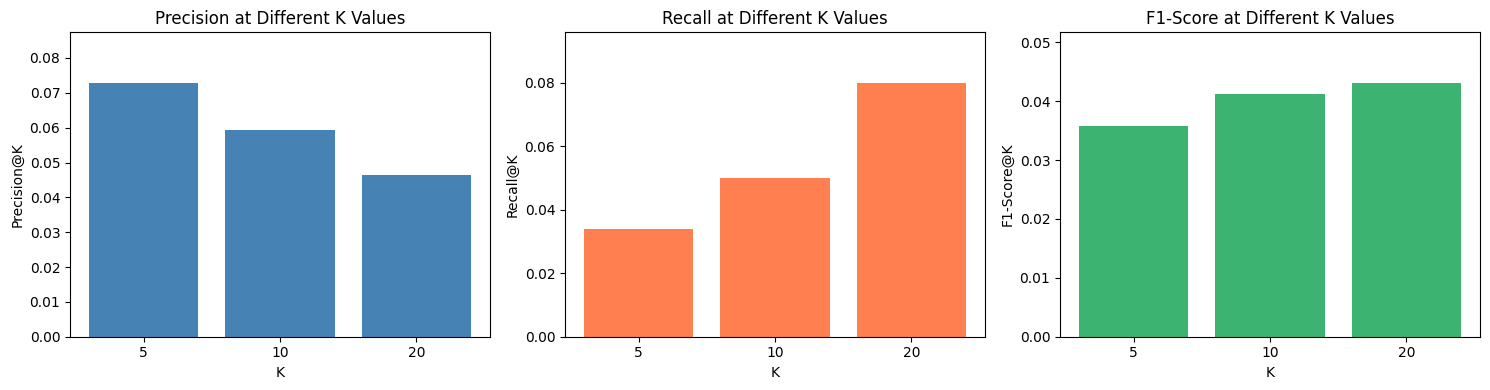

In [9]:
# Prepare data for visualization
metrics_data = []
for k in K_VALUES:
    metrics_data.append({
        'K': k,
        'Precision': np.mean(results[k]['precision']),
        'Recall': np.mean(results[k]['recall']),
        'F1-Score': np.mean(results[k]['f1'])
    })

metrics_df = pd.DataFrame(metrics_data)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Precision
axes[0].bar(metrics_df['K'].astype(str), metrics_df['Precision'], color='steelblue')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision@K')
axes[0].set_title('Precision at Different K Values')
axes[0].set_ylim([0, max(metrics_df['Precision']) * 1.2])

# Recall
axes[1].bar(metrics_df['K'].astype(str), metrics_df['Recall'], color='coral')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Recall@K')
axes[1].set_title('Recall at Different K Values')
axes[1].set_ylim([0, max(metrics_df['Recall']) * 1.2])

# F1-Score
axes[2].bar(metrics_df['K'].astype(str), metrics_df['F1-Score'], color='mediumseagreen')
axes[2].set_xlabel('K')
axes[2].set_ylabel('F1-Score@K')
axes[2].set_title('F1-Score at Different K Values')
axes[2].set_ylim([0, max(metrics_df['F1-Score']) * 1.2])

plt.tight_layout()
plt.show()

## 8. Save CF Model Components

In [10]:
import pickle

print("=== Saving CF Model Components ===")

# Save user similarity matrix
user_similarity_df.to_csv('../models/user_similarity_matrix.csv')
print("✓ Saved: user_similarity_matrix.csv")

# Save evaluation results
with open('../models/cf_evaluation_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("✓ Saved: cf_evaluation_results.pkl")

# Save metrics summary
metrics_df.to_csv('../models/cf_metrics_summary.csv', index=False)
print("✓ Saved: cf_metrics_summary.csv")

print("\nAll CF components saved successfully!")

=== Saving CF Model Components ===
✓ Saved: user_similarity_matrix.csv
✓ Saved: cf_evaluation_results.pkl
✓ Saved: cf_metrics_summary.csv

All CF components saved successfully!


## 9. Summary

In [11]:
print("\n" + "="*70)
print("COLLABORATIVE FILTERING SUMMARY")
print("="*70)

print(f"\n1. MODEL CONFIGURATION")
print(f"   Algorithm: User-Based Collaborative Filtering")
print(f"   Similarity metric: Cosine Similarity")
print(f"   Number of neighbors (K): 10")

print(f"\n2. DATA STATISTICS")
print(f"   Total users: {len(user_item_matrix):,}")
print(f"   Total products: {len(user_item_matrix.columns):,}")
print(f"   Train interactions: {(train_matrix > 0).sum().sum():,}")
print(f"   Test interactions: {(test_matrix > 0).sum().sum():,}")

print(f"\n3. PERFORMANCE METRICS")
for k in K_VALUES:
    print(f"   @{k}: Precision={np.mean(results[k]['precision']):.4f}, "
          f"Recall={np.mean(results[k]['recall']):.4f}, "
          f"F1={np.mean(results[k]['f1']):.4f}")

print(f"\n4. STRENGTHS")
print(f"   ✓ No need for product features")
print(f"   ✓ Captures user behavior patterns")
print(f"   ✓ Can discover unexpected recommendations")

print(f"\n5. LIMITATIONS")
print(f"   ✗ Cold start problem for new users")
print(f"   ✗ Scalability issues with large user base")
print(f"   ✗ Sparsity affects similarity calculation")

print("\n" + "="*70)


COLLABORATIVE FILTERING SUMMARY

1. MODEL CONFIGURATION
   Algorithm: User-Based Collaborative Filtering
   Similarity metric: Cosine Similarity
   Number of neighbors (K): 10

2. DATA STATISTICS
   Total users: 5,545
   Total products: 4,206
   Train interactions: 386,372
   Test interactions: 93,849

3. PERFORMANCE METRICS
   @5: Precision=0.0728, Recall=0.0341, F1=0.0358
   @10: Precision=0.0594, Recall=0.0499, F1=0.0412
   @20: Precision=0.0463, Recall=0.0799, F1=0.0431

4. STRENGTHS
   ✓ No need for product features
   ✓ Captures user behavior patterns
   ✓ Can discover unexpected recommendations

5. LIMITATIONS
   ✗ Cold start problem for new users
   ✗ Scalability issues with large user base
   ✗ Sparsity affects similarity calculation



---
**End of Collaborative Filtering Notebook**

**Next Steps:**
- `04_content_based.ipynb` - Build Content-Based Filtering with TF-IDF
- `05_svd_matrix_factorization.ipynb` - Train SVD model
- `06_hybrid_evaluation.ipynb` - Combine all three algorithms